# Microstructure Analysis

## 1. Metrics

In [2]:
def compute_book_metrics(df_book: pd.DataFrame) -> pd.DataFrame:
    df = df_book.copy()
    best_bid = df["bid_0_price"]
    best_ask = df["ask_0_price"]

    df["mid_price"] = (best_bid + best_ask) / 2

    bid_vol = sum(df[f"bid_{i}_size"] for i in range(5))
    ask_vol = sum(df[f"ask_{i}_size"] for i in range(5))
    total_vol = bid_vol + ask_vol

    df["imbalance"] = (bid_vol - ask_vol) / total_vol
    df["microprice"] = best_ask * bid_vol / total_vol + best_bid * ask_vol / total_vol

    df["mid_return"] = df["mid_price"].pct_change()
    df["next_mid_return"] = df["mid_return"].shift(-1)

    return df[["timestamp", "mid_price", "spread", "imbalance", "microprice", "mid_return", "next_mid_return"]]

df_raw = pd.read_parquet(f"data/raw/book.parquet")
df_metrics = compute_book_metrics(df_raw)
df_metrics.to_parquet(f"data/processed/metrics.parquet")
df = df_metrics.dropna()
print(f"BTC/USDT: {len(df)} snapshots")
print(df.describe())

BTC/USDT: 4998 snapshots
          timestamp     mid_price       spread    imbalance    microprice  \
count  4.998000e+03   4998.000000  4998.000000  4998.000000   4998.000000   
mean   1.776644e+12  74092.806122     0.102241     0.070077  74092.810201   
std    1.475027e+05     35.040004     0.084636     0.614344     35.040590   
min    1.776644e+12  73994.650000     0.100000    -0.999594  73994.647748   
25%    1.776644e+12  74075.750000     0.100000    -0.456993  74075.712728   
50%    1.776644e+12  74104.750000     0.100000     0.116396  74104.791201   
75%    1.776644e+12  74120.350000     0.100000     0.609940  74120.360068   
max    1.776645e+12  74149.750000     5.300000     0.999590  74149.760991   

         mid_return  next_mid_return  
count  4.998000e+03     4.998000e+03  
mean   2.835874e-07     2.835874e-07  
std    2.119438e-05     2.119438e-05  
min   -3.727375e-04    -3.727375e-04  
25%    0.000000e+00     0.000000e+00  
50%    0.000000e+00     0.000000e+00  
75%    0

## 2. Statistical Analysis

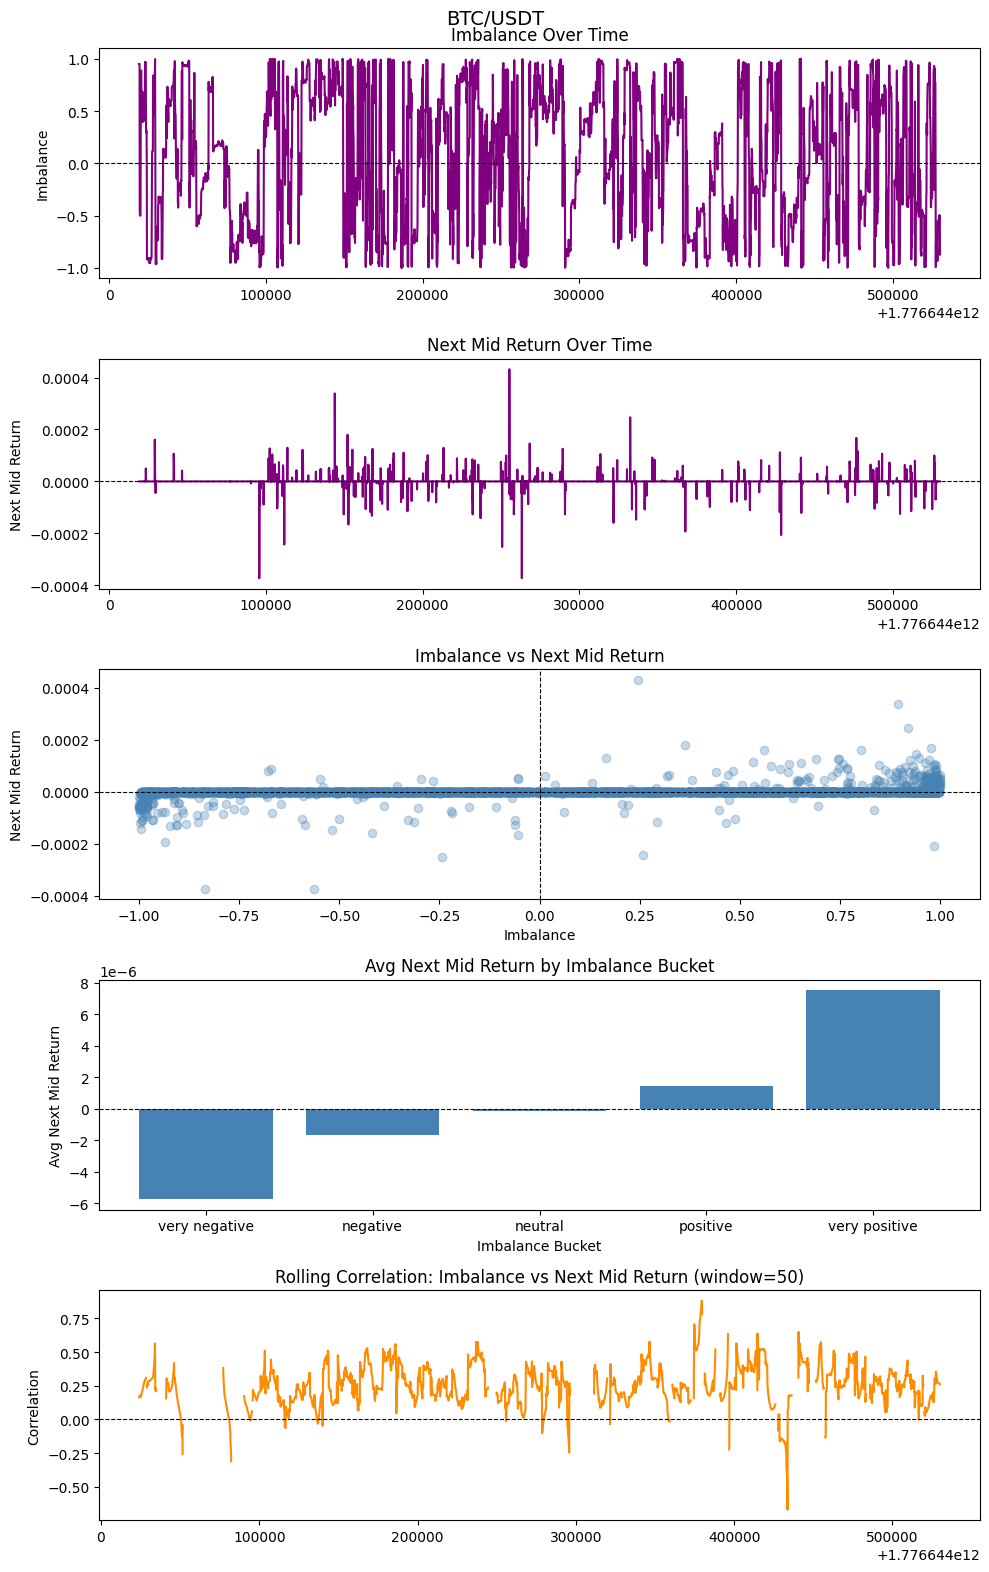

In [5]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_parquet("data/processed/metrics.parquet")

fig, axes = plt.subplots(5, 1, figsize=(10, 16))
fig.suptitle("BTC/USDT", fontsize=14)

# imbalance
axes[0].plot(df["timestamp"], df["imbalance"], color="purple")
axes[0].axhline(0, color="black", linestyle="--", linewidth=0.8)
axes[0].set_title("Imbalance Over Time")
axes[0].set_ylabel("Imbalance")

# next mid return
axes[1].plot(df["timestamp"], df["next_mid_return"], color="purple")
axes[1].axhline(0, color="black", linestyle="--", linewidth=0.8)
axes[1].set_title("Next Mid Return Over Time")
axes[1].set_ylabel("Next Mid Return")

# imbalance vs next mid return
axes[2].scatter(df["imbalance"], df["next_mid_return"], alpha=0.3, color="steelblue")
axes[2].axhline(0, color="black", linestyle="--", linewidth=0.8)
axes[2].axvline(0, color="black", linestyle="--", linewidth=0.8)
axes[2].set_title("Imbalance vs Next Mid Return")
axes[2].set_xlabel("Imbalance")
axes[2].set_ylabel("Next Mid Return")

# quantile bar chart
df["imbalance_bucket"] = pd.qcut(df["imbalance"], q=5, labels=["very negative", "negative", "neutral", "positive", "very positive"])
bucket_means = df.groupby("imbalance_bucket")["next_mid_return"].mean()
axes[3].bar(bucket_means.index, bucket_means.values, color="steelblue")
axes[3].axhline(0, color="black", linestyle="--", linewidth=0.8)
axes[3].set_title("Avg Next Mid Return by Imbalance Bucket")
axes[3].set_ylabel("Avg Next Mid Return")
axes[3].set_xlabel("Imbalance Bucket")

# rolling correlation
rolling_corr = df["imbalance"].rolling(50).corr(df["next_mid_return"])
axes[4].plot(df["timestamp"], rolling_corr, color="darkorange")
axes[4].axhline(0, color="black", linestyle="--", linewidth=0.8)
axes[4].set_title("Rolling Correlation: Imbalance vs Next Mid Return (window=50)")
axes[4].set_ylabel("Correlation")

plt.tight_layout()
plt.savefig("data/processed/plots.png", dpi=150)
plt.show()

### Notes

- Imbalance is positively correlated with next mid return
- Correlation is strongest at extremes (imbalance near ±1)
- Rolling correlation is mostly positive but unstable

**Why?**

one side is thin -> less resistance -> incoming orders consumes more price levels -> larger price move


## 3. Model to predict direction of next mid return

In [6]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import classification_report, accuracy_score

df = pd.read_parquet("data/processed/metrics.parquet")

# target and features
df["target"] = (df["next_mid_return"] > 0).astype(int)
df["imbalance_lag1"] = df["imbalance"].shift(1)
df["imbalance_lag2"] = df["imbalance"].shift(2)
df_model = df.dropna()

X = df_model[["imbalance", "imbalance_lag1", "imbalance_lag2"]]
y = df_model["target"]

# time series cross validation
tscv = TimeSeriesSplit(n_splits=5)
accuracies = []

for fold, (train_idx, test_idx) in enumerate(tscv.split(X)):
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

    model = LogisticRegression()
    model.fit(X_train, y_train)

    acc = accuracy_score(y_test, model.predict(X_test))
    accuracies.append(acc)
    print(f"Fold {fold+1} accuracy: {acc:.3f}")

print(f"\nMean accuracy: {np.mean(accuracies):.3f}")
print(f"\nFeature coefficients:")
for feat, coef in zip(X.columns, model.coef_[0]):
    print(f"  {feat}: {coef:.4f}")

Fold 1 accuracy: 0.910
Fold 2 accuracy: 0.954
Fold 3 accuracy: 0.970
Fold 4 accuracy: 0.972
Fold 5 accuracy: 0.953

Mean accuracy: 0.952

Feature coefficients:
  imbalance: 4.1682
  imbalance_lag1: -0.7509
  imbalance_lag2: -0.3676
